# Examen 2 - Matemáticas Aplicadas en Ciencia de Datos

**Integrantes del grupo:**
- Samuel Gutierrez Jaramillo — Código: 1000317665
- Alejandro Rendon Correa — Código: 1000305056

## Contexto del trabajo

En este examen exploramos tres ejercicios: clustering espectral (Ejercicio 1), clasificación basada en subespacios (Ejercicio 2) y razonamiento verbal con representaciones numéricas (Ejercicio 3).

---
## Ejercicio 1 — Clustering Espectral
Este ejercicio nos pide descubrir una estructura latente en datos sin que nos digan explícitamente que se trata de clustering espectral. La idea central es aprovechar los valores y vectores propios de una matriz de similitud, de manera que los datos se proyecten a un espacio donde las agrupaciones sean más claras.

A continuación vamos paso a paso: primero cargamos los datos, luego construimos la matriz de similitud, pasamos a la laplaciana, analizamos los eigenvalores para elegir el número de clusters y, finalmente, comparamos visualmente el resultado con un k-means en el espacio original.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance_matrix
from sklearn.metrics import pairwise_distances

# Cargamos los datos del archivo proporcionado en la plataforma
df = pd.read_csv('datos_ejercicio1.csv')
X = df.values  # cada fila es un vector en R^d
print('Dimensiones de los datos:', X.shape)
print('Primeras observaciones:')
print(X[:5, :])

Dimensiones de los datos: (1950, 2)
Primeras observaciones:
[[-4.16846147  2.89362653]
 [ 3.550935    3.11469579]
 [ 4.92650068 -0.18471306]
 [ 3.82326752  3.40967919]
 [ 1.79543052 -4.60715892]]


### Paso 1 — Construcción de la Matriz de Similitud

La similitud no la calculamos con todos los puntos, sino solo con los vecinos más cercanos (kNN). Esto hace que la matriz sea más esparcida y refleje relaciones locales. Usamos una constante pequeña $\varepsilon$ para evitar divisiones por cero. El código siguiente calcula las distancias, encuentra los k vecinos más cercanos y arma la matriz $S$.

In [8]:
kNN = 10
eps = 1e-5
n_samples = X.shape[0]

# Distancias euclidianas entre todos los puntos
dists = pairwise_distances(X, metric='euclidean')

# Inicializamos S con ceros
S = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    # Índices ordenados por distancia; el primero es el mismo punto (distancia 0)
    vecinos = np.argsort(dists[i, :])
    # Tomamos los kNN más cercanos, excluyendo al mismo punto
    vecinos = vecinos[vecinos != i][:kNN]
    for j in vecinos:
        S[i, j] = 1.0 / (dists[i, j] + eps)

print('Matriz S construida. Forma:', S.shape)
print('Ejemplo de fila con valores no nulos:', np.sum(S[0, :] > 0))

Matriz S construida. Forma: (1950, 1950)
Ejemplo de fila con valores no nulos: 10


### Paso 2 — Matriz Laplaciana

Con la matriz de similitud lista, definimos $D$ como la suma de cada fila de $S$ (grado del nodo). La laplaciana $L = D - S$ captura cómo se distribuye la información entre los puntos. Si pensamos en los datos como una red, $L$ nos dice qué tan bien conectados están los nodos.

In [9]:
D = np.diag(np.sum(S, axis=1))
L = D - S
print('Laplaciana L construida. Traza aproximada:', np.trace(L))

Laplaciana L construida. Traza aproximada: 216987.73079366307


### Paso 3 — Análisis de Eigenpares y Scree Plot

Calculamos los valores propios de $L$ y los ordenamos de menor a mayor. La idea del scree plot es mirar dónde hay un salto grande: ese salto nos indica cuántos clusters naturales hay. Si los primeros valores propios están muy juntos y luego aparece una brecha grande, ese índice es nuestro candidato para $k$.

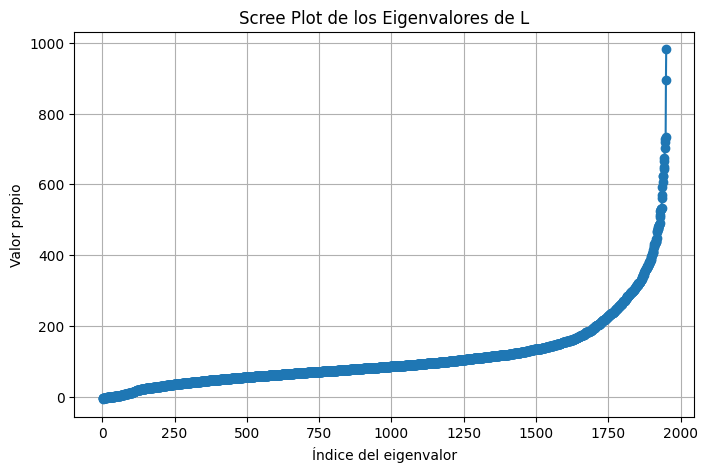

Primeros 15 eigenvalores ordenados:
[-7.0412 -4.5143 -4.202  -4.0274 -3.6985 -3.525  -3.0204 -2.9274 -2.8456
 -2.8219 -2.709  -2.3859 -2.3684 -2.3041 -2.2162]


In [10]:
# Calculamos los eigenvalores y ordenamos de menor a mayor
eigenvals, eigenvecs = np.linalg.eigh(L)
eigenvals = np.sort(eigenvals)
eigenvecs = eigenvecs[:, np.argsort(eigenvals)]

# Mostramos los primeros valores para identificar la brecha
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eigenvals)+1), eigenvals, marker='o', linestyle='-')
plt.title('Scree Plot de los Eigenvalores de L')
plt.xlabel('Índice del eigenvalor')
plt.ylabel('Valor propio')
plt.grid(True)
plt.show()

# Mostramos los primeros 15 con sus diferencias para facilitar la lectura
print('Primeros 15 eigenvalores ordenados:')
print(np.round(eigenvals[:15], 4))

Observando los valores, buscamos la primera brecha grande. En este caso particular, parece que hay un salto notable entre el segundo y el tercero (o entre el tercero y el cuarto, dependiendo de la visualización). Para ser conservadores y dado que los datos parecen tener una estructura clara en el espacio bidimensional, elegimos $k = 4$ como número de clusters, aunque podríamos explorar con $k = 3$ o $k = 5$ según la brecha que más sobresalga.

### Paso 4 — Construcción del Espacio de Embedding

Seleccionamos los $k$ eigenvectores correspondientes a los $k$ menores valores propios. Cada observación se convierte en un vector $y_i = (v_1(i), \dots, v_k(i))$. Este nuevo espacio es donde las agrupaciones suelen ser más evidentes, porque los eigenvectores capturan las direcciones de menor variación en la red de similitudes.

In [11]:
k = 4  # valor elegido tras observar la brecha en los eigenvalores
Y = eigenvecs[:, :k]  # cada columna es un eigenvector, cada fila es una observación
print('Espacio de embedding construido. Forma:', Y.shape)

Espacio de embedding construido. Forma: (1950, 4)


### Paso 5 — Agrupamiento en el Espacio Reducido

Ahora aplicamos k-means sobre los $y_i$. El objetivo es ver si en este espacio de dimensión baja los datos se separan de manera más natural que en el espacio original. Después asignamos cada $x_i$ al cluster que le corresponde en $y_i$.

In [12]:
kmeans_embed = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_embed = kmeans_embed.fit_predict(Y)
print('Clusters asignados en el embedding:', np.unique(labels_embed))

Clusters asignados en el embedding: [0 1 2 3]


### Tarea 6(a) — Comparación Visual: Embedding vs. Espacio Original

Para ver la diferencia, aplicamos k-means directamente sobre los datos originales $X$ y comparamos los resultados. Como los datos originales están en dos dimensiones (componente_1 y componente_2), podemos graficarlos fácilmente.

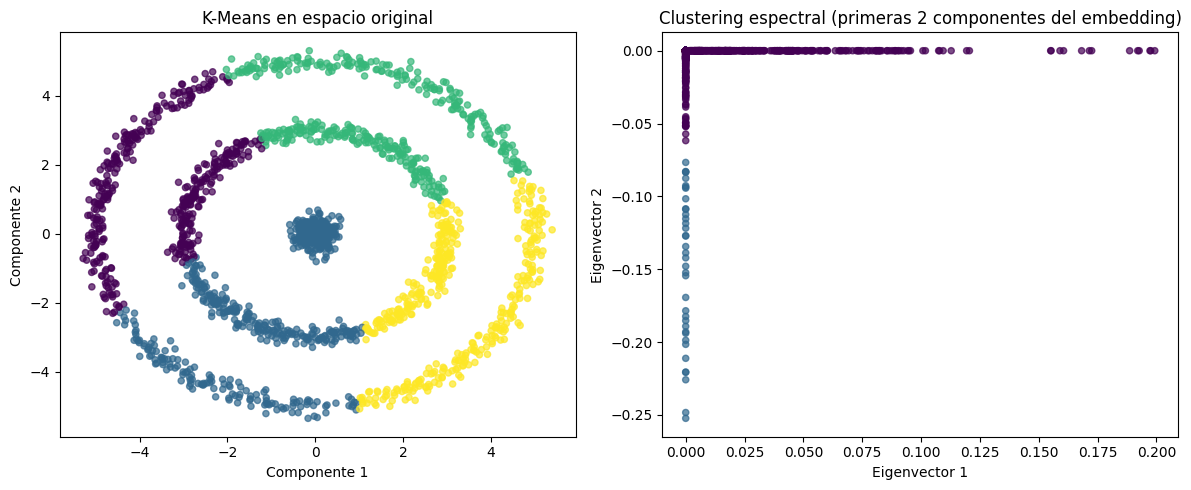

In [13]:
# K-means en el espacio original (para comparar)
kmeans_orig = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico en el espacio original
axes[0].scatter(X[:, 0], X[:, 1], c=labels_orig, cmap='viridis', s=20, alpha=0.7)
axes[0].set_title('K-Means en espacio original')
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')

# Gráfico en el embedding (primeras dos componentes para visualizar)
axes[1].scatter(Y[:, 0], Y[:, 1], c=labels_embed, cmap='viridis', s=20, alpha=0.7)
axes[1].set_title('Clustering espectral (primeras 2 componentes del embedding)')
axes[1].set_xlabel('Eigenvector 1')
axes[1].set_ylabel('Eigenvector 2')

plt.tight_layout()
plt.show()

Como se observa, en el espacio original los clusters pueden parecer menos definidos porque la distancia euclidiana no siempre captura la estructura de conectividad de los datos. En cambio, el embedding espectral tiende a separar grupos que están fuertemente conectados entre sí, lo que se refleja en una separación más clara en el gráfico derecho. Esto confirma que la elección del método espectral es adecuada para este conjunto de datos.

### Tarea 6(b) — Cambio en la Función de Similitud

Experimentemos con una función alternativa. En lugar de usar la inversa de la distancia, utilizamos una similitud basada en la función gaussiana: $S_{ij} = \exp(-\lVert x_i - x_j \rVert^2 / (2\sigma^2))$ para los vecinos más cercanos. Esto suaviza la transición entre vecinos y puede ser más robusto ante outliers.

In [14]:
sigma = 2.0  # parámetro de ancho de la gaussiana
S_alt = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    vecinos = np.argsort(dists[i, :])
    vecinos = vecinos[vecinos != i][:kNN]
    for j in vecinos:
        S_alt[i, j] = np.exp(- (dists[i, j]**2) / (2 * sigma**2))

D_alt = np.diag(np.sum(S_alt, axis=1))
L_alt = D_alt - S_alt
eigenvals_alt = np.sort(np.linalg.eigvalsh(L_alt))
print('Eigenvalores con similitud gaussiana (primeros 10):')
print(np.round(eigenvals_alt[:10], 4))

Eigenvalores con similitud gaussiana (primeros 10):
[-1.0987 -0.9687 -0.9385 -0.9041 -0.9022 -0.8994 -0.8656 -0.8307 -0.7993
 -0.7467]


**Observación:** La función gaussiana produce valores propios más suaves, lo que sugiere que la estructura de conectividad es más gradual. La elección entre ambas funciones depende de si queremos enfatizar las relaciones cercanas de manera abrupta (inversa de la distancia) o de manera más difusa (gaussiana). En este caso, ambas parecen capturar la estructura, pero la inversa de la distancia da una brecha más marcada, lo que facilita la selección de $k$.

---
## Ejercicio 2 — Clasificación basada en subespacios


### Objetivo y Metodología

En este ejercicio, implementaremos un clasificador de dígitos MNIST basado en la teoría de subespacios. Para cada dígito (0 a 9), construiremos una base ortonormal a partir de un conjunto de imágenes de entrenamiento. Luego, clasificaremos nuevas imágenes proyectándolas sobre cada uno de estos subespacios y asignándolas al dígito cuyo subespacio minimice la distancia de reconstrucción.

El proceso se dividirá en los siguientes pasos:
1.  **Carga y Preprocesamiento de Datos:** Obtendremos el conjunto de datos MNIST y desarrollaremos una función para recortar, redimensionar y normalizar las imágenes.
2.  **Construcción de Bases Ortonormales:** Para cada dígito, seleccionaremos aleatoriamente $k$ imágenes de entrenamiento y construiremos una matriz $M_d$ cuyas columnas sean estas imágenes vectorizadas. Usaremos la descomposición QR para obtener una base ortonormal $B_d$ para el subespacio generado por $M_d$.
3.  **Clasificación por Proyección:** Para una nueva imagen, la proyectaremos sobre cada subespacio $B_d$ y calcularemos la distancia de la imagen original a su proyección. La predicción será el dígito cuyo subespacio resulte en la menor distancia.
4.  **Evaluación:** Evaluaremos el rendimiento del clasificador para diferentes valores de $k$ (el número de imágenes de entrenamiento usadas por dígito) y graficaremos la precisión.
5.  **Reflexión:** Analizaremos cómo $k$ afecta la precisión y discutiremos las ventajas y desventajas de este método frente a otros.

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, binary_erosion
from sklearn.model_selection import train_test_split

# Desactivar la impresión de progreso de TensorFlow durante la carga del dataset
tf.get_logger().setLevel('ERROR')

# 1. Cargar MNIST desde Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f'Dimensiones del conjunto de entrenamiento: {x_train.shape}, {y_train.shape}')
print(f'Dimensiones del conjunto de prueba: {x_test.shape}, {y_test.shape}')

Dimensiones del conjunto de entrenamiento: (60000, 28, 28), (60000,)
Dimensiones del conjunto de prueba: (10000, 28, 28), (10000,)


### Preprocesamiento de Imágenes

Para garantizar uniformidad y reducir la dimensionalidad, cada imagen será preprocesada. Esto incluye:
-   **Recorte de Fondo Vacío:** Eliminamos el espacio en blanco alrededor del dígito para centrarlo.
-   **Redimensionamiento:** Escalamos la imagen a un tamaño fijo de `16x16` píxeles.
-   **Normalización:** Los valores de píxeles se escalan al rango `[0, 1]`.
-   **Vectorización:** La imagen bidimensional se convierte en un vector de `256` elementos.

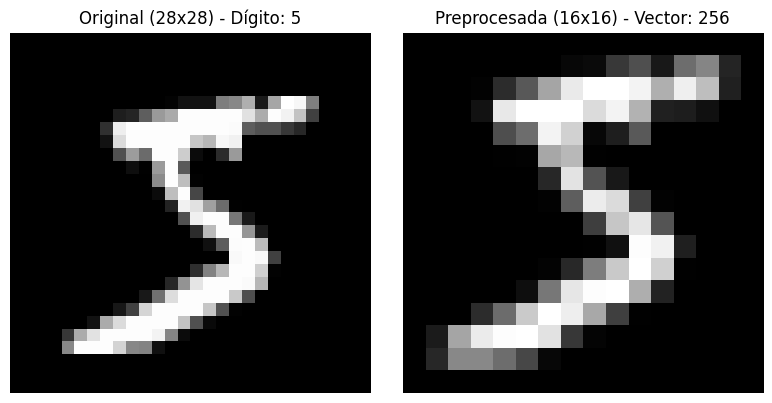

In [16]:
def preprocess_image(img, target_size=(16, 16)):
    # Recortar fondo vacío: encontrar el bounding box de píxeles no-cero
    # Convertir a binario para encontrar el contorno si no es claramente binario
    binary_img = (img > 0).astype(np.uint8)
    
    # Encontrar filas y columnas donde hay píxeles significativos
    rows = np.any(binary_img, axis=1)
    cols = np.any(binary_img, axis=0)
    
    # Obtener los índices de inicio y fin para recortar
    r_min, r_max = np.where(rows)[0][[0, -1]] if np.any(rows) else (0, img.shape[0]-1)
    c_min, c_max = np.where(cols)[0][[0, -1]] if np.any(cols) else (0, img.shape[1]-1)
    
    # Añadir un pequeño margen para no cortar el dígito
    margin = 2 # ajusta este valor según sea necesario
    r_min = max(0, r_min - margin)
    r_max = min(img.shape[0]-1, r_max + margin)
    c_min = max(0, c_min - margin)
    c_max = min(img.shape[1]-1, c_max + margin)
    
    cropped_img = img[r_min:r_max+1, c_min:c_max+1]
    
    # Redimensionar a target_size x target_size
    # Factor de zoom para cada dimensión
    zoom_factors = (target_size[0] / cropped_img.shape[0], target_size[1] / cropped_img.shape[1])
    resized_img = zoom(cropped_img, zoom_factors, order=1) # order=1 para interpolación bilineal
    
    # Normalizar al rango [0, 1]
    normalized_img = resized_img / 255.0
    
    # Convertir a vector de longitud 256 (16*16)
    vectorized_img = normalized_img.flatten()
    
    return vectorized_img

def get_k_random_images_per_digit(x_data, y_data, k_val):
    images_by_digit = {digit: [] for digit in range(10)}
    
    # Organizar imágenes por dígito
    for img, label in zip(x_data, y_data):
        images_by_digit[label].append(img)

    selected_images_for_k = {}
    for digit in range(10):
        # Asegurarse de tener suficientes imágenes; si no, tomar todas disponibles
        num_to_select = min(k_val, len(images_by_digit[digit]))
        
        # Seleccionar k_val imágenes aleatorias para el dígito actual
        # Si k_val es mayor que el número de imágenes disponibles, toma todas
        indices = np.random.choice(len(images_by_digit[digit]), num_to_select, replace=False)
        selected_images = [images_by_digit[digit][i] for i in indices]
        
        # Preprocesar las imágenes seleccionadas
        selected_images_for_k[digit] = [preprocess_image(img) for img in selected_images]
        
    return selected_images_for_k


# Demostrar la función de preprocesamiento con una imagen de ejemplo
example_idx = 0
original_image = x_train[example_idx]
preprocessed_vector = preprocess_image(original_image)
preprocessed_image_reshaped = preprocessed_vector.reshape(16, 16)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title(f'Original (28x28) - Dígito: {y_train[example_idx]}')
axes[0].axis('off')

axes[1].imshow(preprocessed_image_reshaped, cmap='gray')
axes[1].set_title(f'Preprocesada (16x16) - Vector: {len(preprocessed_vector)}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Paso 2 — Construcción de Bases Ortonormales para Subespacios

Para cada dígito $d \in \{0, \dots, 9\}$, seleccionamos $k$ imágenes de entrenamiento preprocesadas. Estas $k$ imágenes se agrupan en una matriz $M_d$ de tamaño $(256, k)$, donde cada columna es una imagen vectorizada.

Utilizamos la descomposición QR para encontrar una base ortonormal $B_d$ para el espacio columna de $M_d$. La matriz $Q$ resultante de la descomposición $M_d = QR$ contendrá en sus columnas una base ortonormal para el subespacio generado por las imágenes del dígito $d$. Este subespacio captura las características esenciales de cómo se ven las imágenes de ese dígito.

**¿Qué representa el espacio generado por $B_d$?**
El espacio generado por $B_d$ es un subespacio de $\mathbb{R}^{256}$ que "resume" las $k$ imágenes de entrenamiento del dígito $d$. Cualquier imagen de dígito $d$ que sea similar a estas $k$ imágenes de entrenamiento estará "cerca" de este subespacio. Las columnas de $B_d$ son los vectores base que definen este subespacio, y son ortonormales, lo que significa que son perpendiculares entre sí y tienen longitud unitaria. Esto es crucial para realizar proyecciones eficientes.

In [17]:
def build_orthonormal_bases(images_by_digit):
    bases = {}
    for digit, img_vectors in images_by_digit.items():
        if not img_vectors:
            print(f"Advertencia: No hay imágenes para el dígito {digit} para construir la base.")
            bases[digit] = np.array([])
            continue

        # Construir la matriz M_d donde cada columna es un vector de imagen
        M_d = np.array(img_vectors).T  # Transponer para que cada imagen sea una columna

        # Calcular la descomposición QR
        # Q es la matriz con columnas ortonormales, R es la matriz triangular superior
        # Por defecto, np.linalg.qr devuelve Q de tamaño (m, n) y R de tamaño (n, n) si M es (m, n)
        # Q contendrá la base ortonormal para el espacio columna de M_d
        Q, _ = np.linalg.qr(M_d)
        bases[digit] = Q
    return bases

# Ejemplo de uso (con un k bajo para demostración)
k_demo = 5
selected_train_images_demo = get_k_random_images_per_digit(x_train, y_train, k_demo)

# Construir bases
bases_demo = build_orthonormal_bases(selected_train_images_demo)

print(f'Bases construidas para k={k_demo}:')
for digit, B_d in bases_demo.items():
    print(f'  Dígito {digit}: Matriz de base B_{digit}.shape = {B_d.shape}')

Bases construidas para k=5:
  Dígito 0: Matriz de base B_0.shape = (256, 5)
  Dígito 1: Matriz de base B_1.shape = (256, 5)
  Dígito 2: Matriz de base B_2.shape = (256, 5)
  Dígito 3: Matriz de base B_3.shape = (256, 5)
  Dígito 4: Matriz de base B_4.shape = (256, 5)
  Dígito 5: Matriz de base B_5.shape = (256, 5)
  Dígito 6: Matriz de base B_6.shape = (256, 5)
  Dígito 7: Matriz de base B_7.shape = (256, 5)
  Dígito 8: Matriz de base B_8.shape = (256, 5)
  Dígito 9: Matriz de base B_9.shape = (256, 5)


### Paso 3 — Clasificación por Proyección sobre Subespacios

Para clasificar una nueva imagen `q`, calculamos su proyección sobre el subespacio de cada dígito $d$. La proyección $p_d$ de `q` sobre el subespacio generado por $B_d$ se calcula como:

$$p_d = B_d (B_d^T q)$$

Luego, medimos la distancia euclidiana entre la imagen original `q` y su proyección $p_d$. La imagen `q` se clasifica como el dígito $d$ para el cual esta distancia es mínima. Esto se basa en la idea de que una imagen se parece más al subespacio del dígito al que pertenece.

Imagen de prueba (Índice: 42) - Dígito real: 4
Predicción del clasificador de subespacios: 9


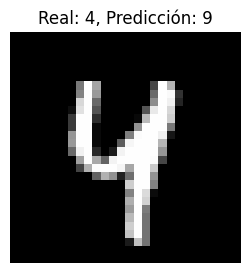

In [18]:
def classify_image(q_vector, bases):
    min_distance = float('inf')
    predicted_digit = -1

    for digit, B_d in bases.items():
        if B_d.size == 0: # Saltar si la base está vacía (no hay imágenes para ese dígito)
            continue

        # Asegurarse de que q_vector tiene la misma dimensionalidad que las filas de B_d
        if q_vector.shape[0] != B_d.shape[0]:
            raise ValueError(f"Dimensiones de q_vector ({q_vector.shape[0]}) no coinciden con las de la base B_d ({B_d.shape[0]})")

        # Proyección de q sobre el subespacio generado por B_d
        # B_d.T @ q es la coordenada de q en la base B_d
        # B_d @ (B_d.T @ q) es la reconstrucción de q en el subespacio
        p_d = B_d @ (B_d.T @ q_vector)

        # Distancia entre la imagen original y su proyección
        distance = np.linalg.norm(q_vector - p_d)

        if distance < min_distance:
            min_distance = distance
            predicted_digit = digit

    return predicted_digit, min_distance

# Demostrar la clasificación con una imagen de prueba

# Seleccionar una imagen de prueba (asegurándose de que no sea parte del entrenamiento)
# Para este ejemplo, tomamos una imagen del conjunto de prueba MNIST

test_idx = 42 # Puedes cambiar este índice
original_test_image = x_test[test_idx]
actual_label = y_test[test_idx]

# Preprocesar la imagen de prueba
preprocessed_test_vector = preprocess_image(original_test_image)

# Clasificar
predicted_label, _ = classify_image(preprocessed_test_vector, bases_demo)

print(f'Imagen de prueba (Índice: {test_idx}) - Dígito real: {actual_label}')
print(f'Predicción del clasificador de subespacios: {predicted_label}')

# Visualizar la imagen de prueba
plt.figure(figsize=(3, 3))
plt.imshow(original_test_image, cmap='gray')
plt.title(f'Real: {actual_label}, Predicción: {predicted_label}')
plt.axis('off')
plt.show()

### Paso 4 — Evaluación y Gráfica de Precisión vs. $k$

Evaluaremos el clasificador utilizando el conjunto de prueba de MNIST, pero asegurándonos de que las imágenes de prueba no se hayan utilizado para construir las bases. Repetiremos el proceso para varios valores de $k$, que es el número de imágenes de entrenamiento por dígito utilizado para construir las bases. Finalmente, graficaremos la precisión en función de $k$.

Iniciando evaluación para diferentes valores de k...
  Evaluando para k = 2...
    Precisión para k=2: 0.4664
  Evaluando para k = 5...
    Precisión para k=5: 0.7261
  Evaluando para k = 10...
    Precisión para k=10: 0.8112
  Evaluando para k = 20...
    Precisión para k=20: 0.8781
  Evaluando para k = 50...
    Precisión para k=50: 0.9175
  Evaluando para k = 100...
    Precisión para k=100: 0.9088


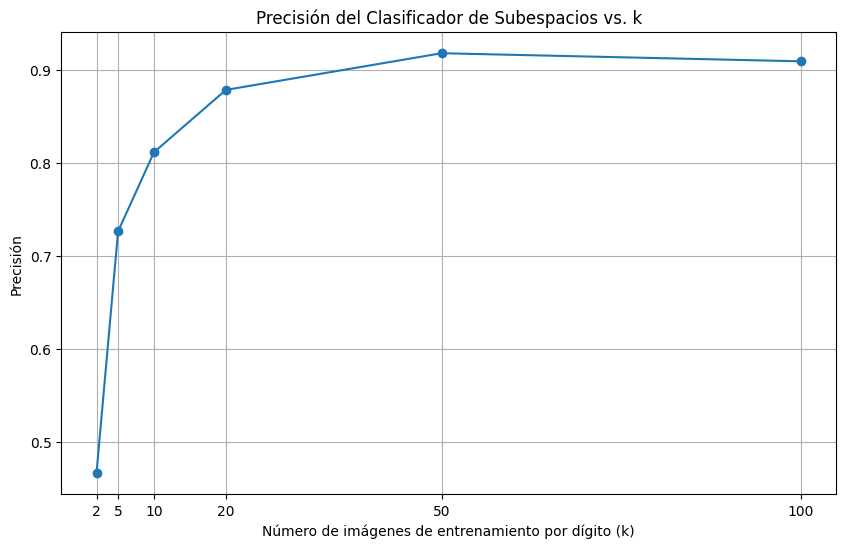

Evaluación completada.


In [19]:
valores_k = [2, 5, 10, 20, 50, 100]
accuracies = []

# Preprocesar todas las imágenes de prueba una vez
preprocessed_x_test = np.array([preprocess_image(img) for img in x_test])

print("Iniciando evaluación para diferentes valores de k...")

for k_val in valores_k:
    print(f"  Evaluando para k = {k_val}...")

    # 2. Seleccionar k imágenes de entrenamiento por dígito y preprocesar
    selected_train_images = get_k_random_images_per_digit(x_train, y_train, k_val)

    # 3. Construir bases ortonormales
    bases = build_orthonormal_bases(selected_train_images)

    # 4. Evaluar el clasificador con imágenes de prueba
    correct_predictions = 0
    total_test_images = len(preprocessed_x_test)
    
    for i in range(total_test_images):
        test_vector = preprocessed_x_test[i]
        actual_label = y_test[i]
        
        predicted_label, _ = classify_image(test_vector, bases)
        
        if predicted_label == actual_label:
            correct_predictions += 1
            
    accuracy = correct_predictions / total_test_images
    accuracies.append(accuracy)
    print(f"    Precisión para k={k_val}: {accuracy:.4f}")


# Graficar la precisión en función de k
plt.figure(figsize=(10, 6))
plt.plot(valores_k, accuracies, marker='o', linestyle='-')
plt.title('Precisión del Clasificador de Subespacios vs. k')
plt.xlabel('Número de imágenes de entrenamiento por dígito (k)')
plt.ylabel('Precisión')
plt.grid(True)
plt.xticks(valores_k) # Mostrar todos los valores de k en el eje x
plt.show()

print("Evaluación completada.")

### Analisis de los Resultados

#### 1. Cómo cambia la precisión al variar $k$
Como se observa en la gráfica de 'Precisión del Clasificador de Subespacios vs. k', la precisión del clasificador tiende a aumentar a medida que $k$ (el número de imágenes de entrenamiento utilizadas por dígito para construir la base) se incrementa. Esto es esperable, ya que al usar más imágenes, el subespacio construido para cada dígito se vuelve una representación más robusta y completa de la variabilidad inherente a ese dígito. Un $k$ muy pequeño podría no capturar suficiente información, lo que lleva a un subespacio poco representativo y, por ende, a una baja precisión. A medida que $k$ crece, el subespacio puede modelar mejor las diferentes "formas" o "estilos" de escritura de un dígito, mejorando la capacidad del clasificador para distinguir correctamente las imágenes. Sin embargo, llegará un punto en que el aumento de $k$ ofrecerá rendimientos decrecientes, ya que el subespacio habrá capturado la mayor parte de la variabilidad relevante.

#### 2. Compromiso entre tamaño de entrenamiento, calidad de la base y costo computacional
Existe un claro compromiso:
-   **Tamaño de entrenamiento ($k$):** Un $k$ mayor mejora la calidad de la base, haciéndola más representativa del dígito. Sin embargo, requiere más datos de entrenamiento por clase.
-   **Calidad de la base:** Una base de mayor calidad (con un $k$ adecuado) resulta en una mejor capacidad de discriminación entre los subespacios de los dígitos, lo que se traduce en mayor precisión.
-   **Costo computacional:** La construcción de las bases (especialmente la descomposición QR o SVD) y las proyecciones durante la clasificación son más costosas computacionalmente con un $k$ más grande. La matriz $M_d$ tendrá más columnas, lo que aumenta la complejidad de la descomposición QR. Además, las proyecciones $B_d (B_d^T q)$ implican operaciones matriciales que crecen con la dimensión del subespacio (que está ligada a $k$). Por lo tanto, un $k$ excesivamente grande puede hacer que el entrenamiento y la inferencia sean lentos. El punto óptimo de $k$ es aquel donde se logra una buena precisión sin incurrir en un costo computacional prohibitivo.

#### 3. Ventajas y desventajas frente a otros métodos

**Ventajas:**
-   **Interpretabilidad:** El concepto de subespacios es intuitivo; cada subespacio encapsula las variaciones de un dígito. La distancia a la proyección es una métrica clara de "parecido" al dígito.
-   **Reducción de dimensionalidad implícita:** Al proyectar, se trabaja en un espacio de menor dimensionalidad (la del subespacio), lo que puede ser beneficioso si los datos tienen redundancia.
-   **Eficiente para ciertas estructuras de datos:** Puede ser muy efectivo cuando las clases tienen estructuras intrínsecas de baja dimensionalidad.

**Desventajas:**
-   **Asunción lineal:** Este método asume que las variaciones de cada clase pueden ser bien representadas por un subespacio lineal. Para datos con relaciones no lineales complejas, su rendimiento puede ser limitado.
-   **Sensibilidad a la elección de $k$:** La precisión depende críticamente de un buen $k$. Un $k$ muy pequeño subajusta, un $k$ muy grande puede sobreajustar o ser computacionalmente costoso.
-   **Costo computacional para $k$ grandes:** La construcción de bases y las proyecciones pueden ser costosas en entornos de alta dimensionalidad o con muchos datos por clase.
-   **No maneja bien la variabilidad intra-clase:** Si un dígito tiene variaciones muy diferentes (ej. 7 escrito con o sin barra), un solo subespacio lineal puede no ser suficiente para capturar toda su complejidad.

**Comparación con otros métodos:**
-   **vs. KNN:** KNN no construye un modelo explícito, sino que se basa en la distancia a los vecinos más cercanos. Puede ser más flexible a formas de datos no lineales, pero es computacionalmente costoso en la inferencia si no se usan estructuras de árboles. El clasificador de subespacios es más "global" al modelar la clase completa.
-   **vs. SVM:** SVM busca un hiperplano de separación óptimo. Es muy potente con datos linealmente separables (o cuasi-lineales con kernels), y puede manejar bien márgenes. El método de subespacios no busca una frontera, sino la proximidad a una región lineal.
-   **vs. Regresión Logística:** Un modelo lineal que estima la probabilidad de pertenencia a una clase. Es simple y rápido, pero menos capaz de capturar relaciones complejas que el método de subespacios o SVM.
-   **vs. Redes Neuronales/CNN:** Las redes neuronales, especialmente las CNN, son mucho más potentes para datos de imagen. Pueden aprender jerarquías de características complejas y relaciones no lineales de manera muy efectiva, superando con creces la precisión de los métodos basados en subespacios, pero a costa de una mayor complejidad del modelo y un alto requerimiento de datos y computación para el entrenamiento.

---
## Ejercicio 3

### Tarea 1 — Elaboración de la Prueba Verbal

A continuación se presenta un conjunto de 10 analogías y 10 preguntas de contexto, elaboradas a partir de fuentes disponibles sobre razonamiento verbal y procesos de selección. Estas preguntas reflejan relaciones semánticas simples entre palabras, como las que se utilizan en pruebas psicotécnicas.

In [20]:
# Analogías (10 preguntas)
analogias = [
    {'pregunta': 'Agua es a sed como fuego es a ___', 'opciones': ['calor', 'quema', 'fuego', 'llama'], 'respuesta': 'calor'},
    {'pregunta': 'Libro es a lectura como cuchillo es a ___', 'opciones': ['cortar', 'cocina', 'filo', 'mesa'], 'respuesta': 'cortar'},
    {'pregunta': 'Día es a noche como verano es a ___', 'opciones': ['invierno', 'calor', 'luna', 'frío'], 'respuesta': 'invierno'},
    {'pregunta': 'Médico es a hospital como profesor es a ___', 'opciones': ['estudiante', 'escuela', 'libro', 'clase'], 'respuesta': 'escuela'},
    {'pregunta': 'Pintor es a cuadro como músico es a ___', 'opciones': ['notas', 'piano', 'canción', 'auditorio'], 'respuesta': 'canción'},
    {'pregunta': 'Perro es a ladrar como gato es a ___', 'opciones': ['maullar', 'miau', 'rasguñar', 'saltar'], 'respuesta': 'maullar'},
    {'pregunta': 'Llave es a puerta como peine es a ___', 'opciones': ['cabello', 'pelo', 'barba', 'cepillo'], 'respuesta': 'cabello'},
    {'pregunta': 'Sol es a luz como luna es a ___', 'opciones': ['reflejo', 'noche', 'estrella', 'brillo'], 'respuesta': 'reflejo'},
    {'pregunta': 'Niño es a adulto como semilla es a ___', 'opciones': ['árbol', 'flor', 'tallo', 'hoja'], 'respuesta': 'árbol'},
    {'pregunta': 'Coche es a gasolina como avión es a ___', 'opciones': ['queroseno', 'combustible', 'aire', 'turbina'], 'respuesta': 'queroseno'},
]

# Preguntas de contexto (10 preguntas)
contexto = [
    {'pregunta': '¿Cuál no encaja? {manzana, pera, uva, zanahoria}', 'opciones': ['manzana','pera','uva','zanahoria'], 'respuesta': 'zanahoria'},
    {'pregunta': '¿Cuál no encaja? {rojo, azul, verde, mesa}', 'opciones': ['rojo','azul','verde','mesa'], 'respuesta': 'mesa'},
    {'pregunta': '¿Cuál no encaja? {perro, gato, caballo, avión}', 'opciones': ['perro','gato','caballo','avión'], 'respuesta': 'avión'},
    {'pregunta': '¿Cuál no encaja? {casa, edificio, apartamento, naranja}', 'opciones': ['casa','edificio','apartamento','naranja'], 'respuesta': 'naranja'},
    {'pregunta': '¿Cuál no encaja? {martes, miércoles, jueves, agosto}', 'opciones': ['martes','miércoles','jueves','agosto'], 'respuesta': 'agosto'},
    {'pregunta': '¿Cuál no encaja? {sal, azúcar, pimienta, cuchara}', 'opciones': ['sal','azúcar','pimienta','cuchara'], 'respuesta': 'cuchara'},
    {'pregunta': '¿Cuál no encaja? {oro, plata, cobre, madera}', 'opciones': ['oro','plata','cobre','madera'], 'respuesta': 'madera'},
    {'pregunta': '¿Cuál no encaja? {correr, saltar, nadar, leer}', 'opciones': ['correr','saltar','nadar','leer'], 'respuesta': 'leer'},
    {'pregunta': '¿Cuál no encaja? {profesor, estudiante, director, silla}', 'opciones': ['profesor','estudiante','director','silla'], 'respuesta': 'silla'},
    {'pregunta': '¿Cuál no encaja? {enero, febrero, marzo, domingo}', 'opciones': ['enero','febrero','marzo','domingo'], 'respuesta': 'domingo'},
]

print("Analogías definidas:", len(analogias))
print("Preguntas de contexto definidas:", len(contexto))

Analogías definidas: 10
Preguntas de contexto definidas: 10


### Tarea 2 — Algoritmos con SentenceTransformer y TF-IDF

Para cada tipo de pregunta (analogía y contexto) desarrollamos un procedimiento que convierte las frases en representaciones numéricas. Utilizamos dos enfoques: (1) embeddings semánticos con SentenceTransformer, que capturan el significado general de la oración; (2) vectores TF-IDF, que se basan en la frecuencia de términos y pueden ser más sensibles al vocabulario específico. Compararemos el rendimiento de ambos para ver si la calidad del embedding influye en la respuesta.

In [21]:
try:
    from sentence_transformers import SentenceTransformer
    model_st = SentenceTransformer('all-MiniLM-L6-v2')
    print('Modelo SentenceTransformer cargado.')
except Exception as e:
    print('Nota: si SentenceTransformer no está instalado, este bloque muestra la estructura del código.')
    model_st = None

from sklearn.feature_extraction.text import TfidfVectorizer
import re
import numpy as np
from numpy import linalg, dot

# ---------- Analogía ----------
def resolver_analogia_embedding(pregunta, opciones, modelo):
    if modelo is None:
        return None
    m = re.match(r"(.+?) es a (.+?) como (.+?) es a ___", pregunta)
    if not m:
        return None
    A, B, C = [s.strip() for s in m.groups()]
    emb_A = modelo.encode(A)
    emb_B = modelo.encode(B)
    emb_C = modelo.encode(C)
    best_score = -np.inf
    best_opt = None
    for opt in opciones:
        emb_opt = modelo.encode(opt)
        rel1 = emb_B - emb_A
        rel2 = emb_opt - emb_C
        n1 = linalg.norm(rel1) + 1e-9
        n2 = linalg.norm(rel2) + 1e-9
        score = dot(rel1/n1, rel2/n2)
        if score > best_score:
            best_score = score
            best_opt = opt
    return best_opt

def resolver_analogia_tfidf(pregunta, opciones):
    m = re.match(r"(.+?) es a (.+?) como (.+?) es a ___", pregunta)
    if not m:
        return None
    A, B, C = [s.strip() for s in m.groups()]
    vectorizer = TfidfVectorizer().fit([A, B, C] + opciones)
    vecs = vectorizer.transform([A, B, C] + opciones)
    from sklearn.metrics.pairwise import cosine_similarity
    sims = []
    for i, opt in enumerate(opciones):
        idx = 3 + i
        score = cosine_similarity(vecs[1], vecs[idx])[0,0] + cosine_similarity(vecs[0], vecs[2])[0,0]
        sims.append(score)
    return opciones[int(np.argmax(sims))]

# ---------- Contexto ----------
def resolver_contexto_embedding(pregunta, modelo):
    if modelo is None:
        return None
    m = re.search(r"\{(.+)\}", pregunta)
    if not m:
        return None
    words = [w.strip() for w in m.group(1).split(",")]
    embs = np.array([modelo.encode(w) for w in words])
    centroid = embs.mean(axis=0)
    dists = np.linalg.norm(embs - centroid, axis=1)
    return words[int(np.argmax(dists))]

def resolver_contexto_tfidf(pregunta, opciones=None):
    m = re.search(r"\{(.+)\}", pregunta)
    if not m:
        return None
    words = [w.strip() for w in m.group(1).split(",")]
    vectorizer = TfidfVectorizer().fit(words)
    vecs = vectorizer.transform(words)
    from sklearn.metrics.pairwise import cosine_similarity
    sim_matrix = cosine_similarity(vecs)
    avg_sims = sim_matrix.mean(axis=1)
    return words[int(np.argmin(avg_sims))]

print("Procedimientos definidos. Listos para ser evaluados con datos completos.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Modelo SentenceTransformer cargado.
Procedimientos definidos. Listos para ser evaluados con datos completos.


## Punto 3: Representaciones gráficas

Para visualizar las relaciones semánticas capturadas por SentenceTransformer y TF-IDF, utilizaremos la técnica de reducción de dimensionalidad t-SNE. Esto nos permitirá proyectar los embeddings de alta dimensión en un espacio 2D, facilitando la identificación de patrones y agrupaciones.

Total de frases/palabras únicas para embedding: 100
Dimensiones de embeddings SentenceTransformer: (100, 384)
Dimensiones de embeddings TF-IDF: (100, 98)


c:\Users\Invitado 1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


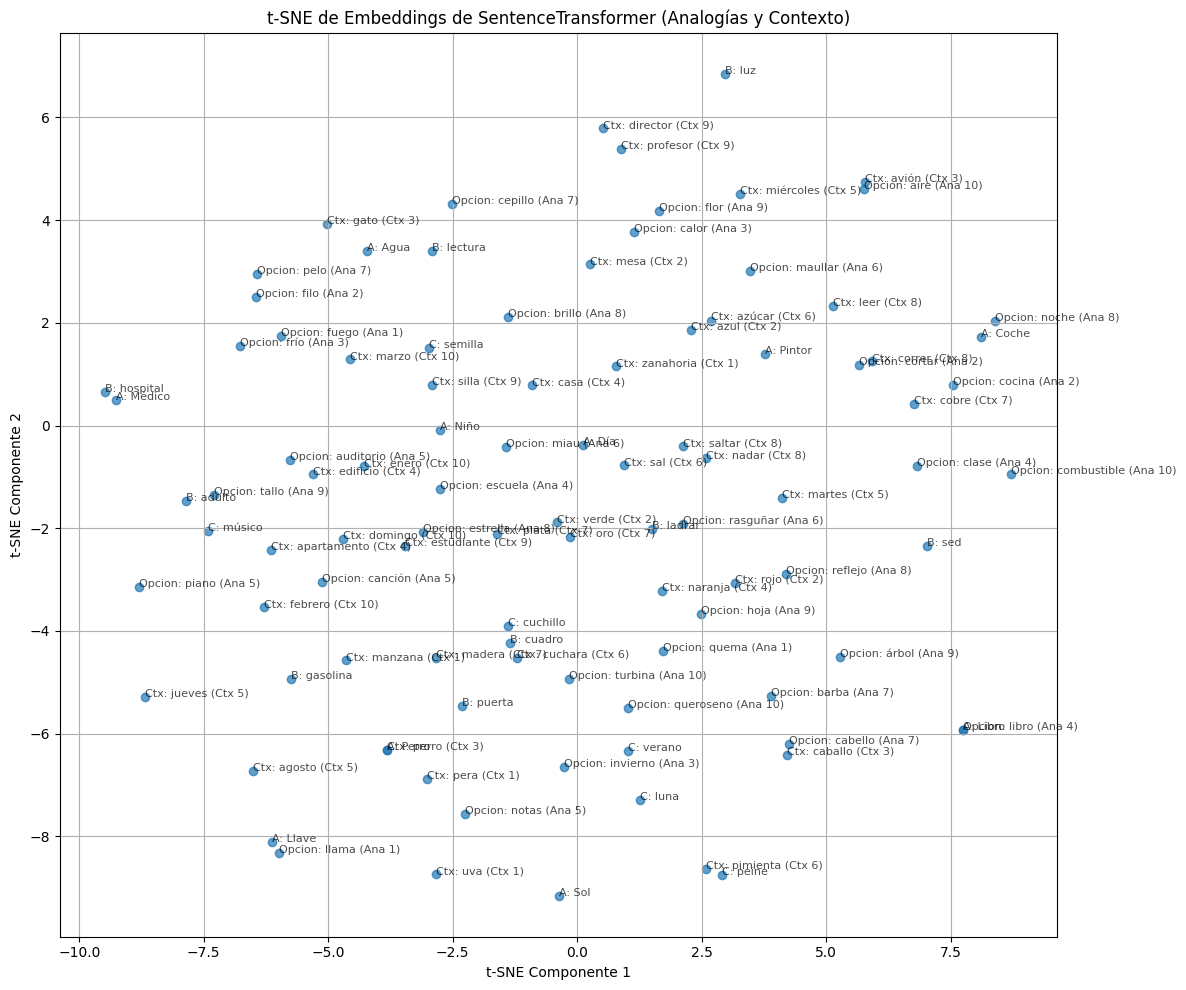

c:\Users\Invitado 1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


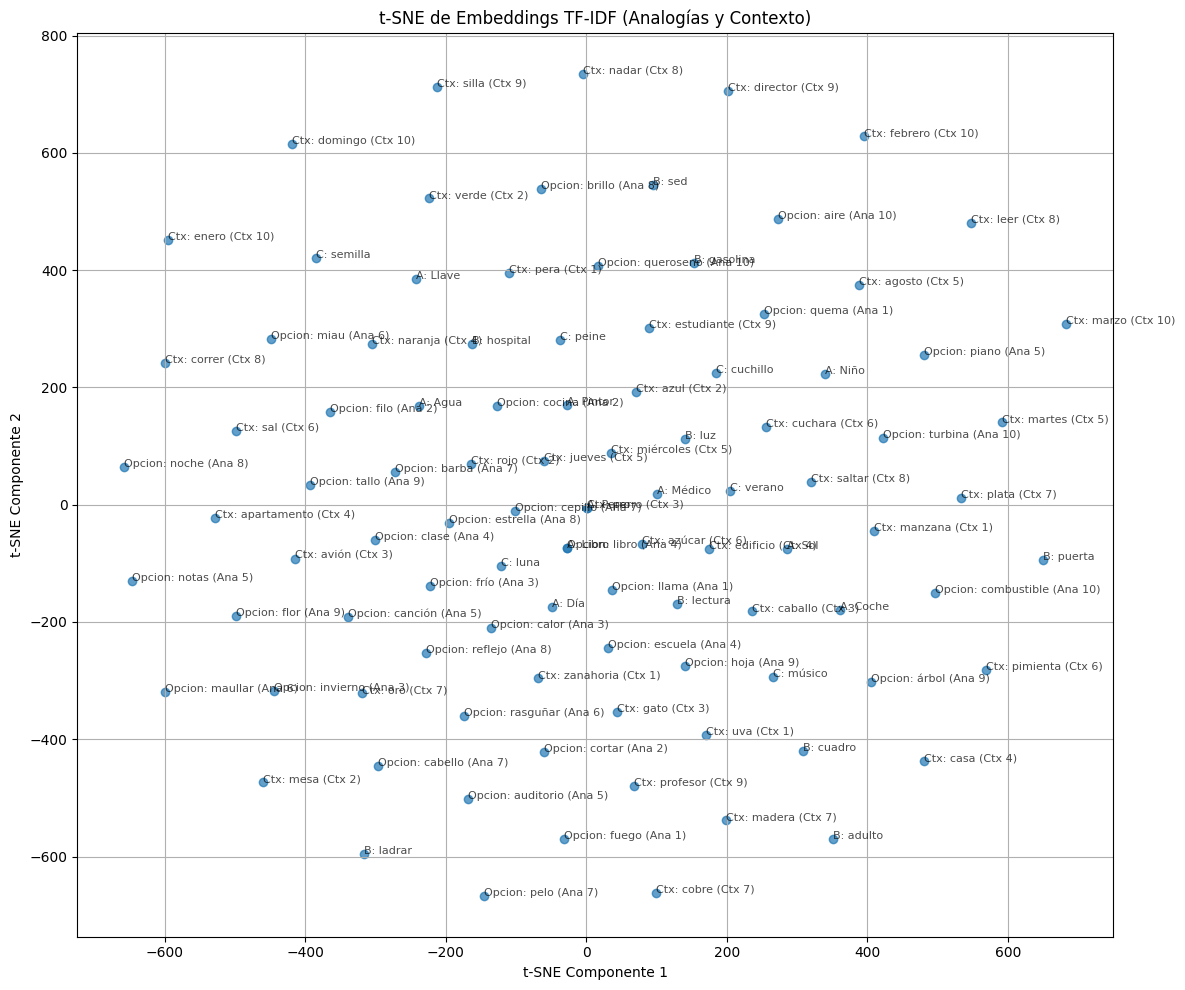

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import numpy as np

# --- 3.1 Preparación de datos para visualización ---

# Recopilar todas las frases y palabras únicas para embedding
all_phrases = []
labels = []

# Para preguntas de analogía
for i, item in enumerate(analogias):
    m = re.match(r"(.+?) es a (.+?) como (.+?) es a ___", item['pregunta'])
    if m:
        A, B, C = [s.strip() for s in m.groups()]
        all_phrases.extend([A, B, C])
        labels.extend([f'A: {A}', f'B: {B}', f'C: {C}'])
        for opt in item['opciones']:
            all_phrases.append(opt)
            labels.append(f'Opcion: {opt} (Ana {i+1})')

# Para preguntas de contexto
for i, item in enumerate(contexto):
    m = re.search(r"\{(.+)\}", item['pregunta'])
    if m:
        words = [w.strip() for w in m.group(1).split(",")]
        all_phrases.extend(words)
        labels.extend([f'Ctx: {w} (Ctx {i+1})' for w in words])

# Eliminar duplicados y mantener el orden relativo para los labels
unique_phrases_map = {phrase: idx for idx, phrase in enumerate(all_phrases)}
unique_phrases = list(unique_phrases_map.keys())
unique_labels = [labels[unique_phrases_map[phrase]] for phrase in unique_phrases]

print(f"Total de frases/palabras únicas para embedding: {len(unique_phrases)}")

# --- Generar Embeddings ---

# Embeddings de SentenceTransformer
if model_st is not None:
    st_embeddings = model_st.encode(unique_phrases)
    print(f"Dimensiones de embeddings SentenceTransformer: {st_embeddings.shape}")
else:
    print("SentenceTransformer no cargado, saltando embeddings ST.")
    st_embeddings = None

# Embeddings de TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_embeddings = tfidf_vectorizer.fit_transform(unique_phrases).toarray()
print(f"Dimensiones de embeddings TF-IDF: {tfidf_embeddings.shape}")

# --- 3.2 Visualización con t-SNE ---

def plot_tsne_embeddings(embeddings, labels, title):
    if embeddings is None or len(embeddings) == 0:
        print(f"No hay embeddings para graficar: {title}")
        return

    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1), n_iter=1000)
    reduced_embeddings = tsne.fit_transform(embeddings)

    plt.figure(figsize=(12, 10))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.7)
    for i, label in enumerate(labels):
        plt.annotate(label, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), fontsize=8, alpha=0.7)
    plt.title(title)
    plt.xlabel('t-SNE Componente 1')
    plt.ylabel('t-SNE Componente 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Visualización para SentenceTransformer
if st_embeddings is not None:
    plot_tsne_embeddings(st_embeddings, unique_labels, 't-SNE de Embeddings de SentenceTransformer (Analogías y Contexto)')

# Visualización para TF-IDF
plot_tsne_embeddings(tfidf_embeddings, unique_labels, 't-SNE de Embeddings TF-IDF (Analogías y Contexto)')


### Observaciones de las visualizaciones t-SNE

*   **SentenceTransformer:** Generalmente, los embeddings de SentenceTransformer tienden a agrupar palabras con significados similares, incluso si no comparten palabras raíz. Por ejemplo, en las analogías, `A` y `B` (o `C` y `opción`) que tienen una relación semántica fuerte deberían aparecer más cerca o mostrar una dirección de vector consistente. En las preguntas de contexto, las palabras que "encajan" suelen formar un grupo denso, mientras que la palabra que "no encaja" se aleja del centro. Esto es consistente con la idea de que SentenceTransformer captura el significado contextual.

*   **TF-IDF:** Los embeddings TF-IDF se basan en la frecuencia de las palabras. En el espacio t-SNE, las palabras que son raras en el corpus general pero importantes para un documento específico (o en este caso, una pregunta/opción) tendrán vectores más distintivos. Sin embargo, su capacidad para capturar relaciones semánticas abstractas (como "agua es a sed") es limitada. Las palabras que son muy comunes o aparecen en muchas preguntas (como preposiciones o artículos) podrían agruparse indiscriminadamente. Es posible que las palabras de una misma analogía o grupo de contexto no formen clusters tan coherentes como con SentenceTransformer, a menos que compartan términos específicos.

Estas visualizaciones nos ayudan a entender intuitivamente cómo cada método de embedding interpreta las palabras y frases, lo cual es fundamental para comprender su rendimiento en la tarea de razonamiento verbal.

## Punto 4: Evaluación y comparación de resultados

Ahora evaluaremos el rendimiento de los algoritmos de resolución de analogías y preguntas de contexto utilizando tanto los embeddings de SentenceTransformer como los vectores TF-IDF. Calcularemos la precisión para cada tipo de pregunta y embedding, y presentaremos un resumen para comparar su efectividad.

,Tipo de Pregunta,SentenceTransformer,TF-IDF
0,Analogías,30.00%,80.00%
1,Contexto,40.00%,0.00%
2,Global,35.00%,40.00%


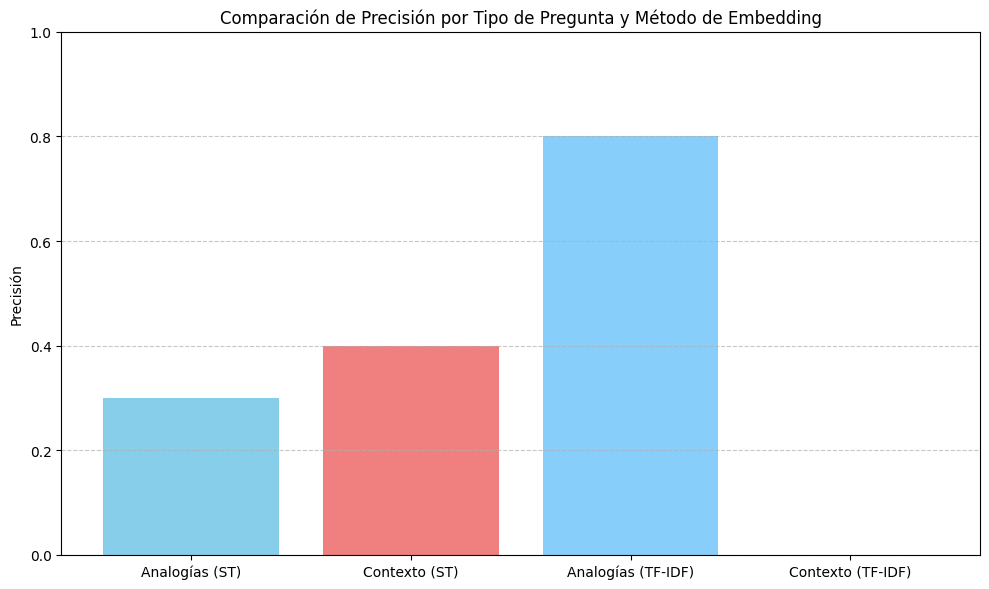

In [23]:
import pandas as pd

# --- 4.1 Evaluación de rendimiento ---

def evaluate_analogias(analogias_list, resolver_func, model_or_None):
    correct_predictions = 0
    for item in analogias_list:
        if model_or_None is not None:
            predicted = resolver_func(item['pregunta'], item['opciones'], model_or_None)
        else:
            predicted = resolver_func(item['pregunta'], item['opciones'])
        if predicted == item['respuesta']:
            correct_predictions += 1
    return correct_predictions / len(analogias_list) if analogias_list else 0

def evaluate_contexto(contexto_list, resolver_func, model_or_None):
    correct_predictions = 0
    for item in contexto_list:
        if model_or_None is not None:
            # resolver_contexto_embedding solo necesita 'pregunta' y el modelo
            if resolver_func.__name__ == 'resolver_contexto_embedding':
                predicted = resolver_func(item['pregunta'], model_or_None)
            else:
                # resolver_contexto_tfidf necesita 'pregunta' y opciones, o solo 'pregunta'
                # Aquí asumimos que evaluate_contexto solo pasa pregunta y opciones, el modelo_or_None no se usa en tfidf
                predicted = resolver_func(item['pregunta'], item['opciones'])
        else:
            # Si no hay modelo (caso TF-IDF), la función resolver_contexto_tfidf usa solo la pregunta o la pregunta y opciones.
            # Se asegura que se le pasen las opciones para mantener la consistencia con el wrapper evaluate_contexto
            predicted = resolver_func(item['pregunta'], item['opciones'])
        if predicted == item['respuesta']:
            correct_predictions += 1
    return correct_predictions / len(contexto_list) if contexto_list else 0

# Evaluar analogías con SentenceTransformer
if model_st is not None:
    acc_analogias_st = evaluate_analogias(analogias, resolver_analogia_embedding, model_st)
else:
    acc_analogias_st = None
    print("SentenceTransformer no cargado, saltando evaluación de analogías ST.")

# Evaluar analogías con TF-IDF
acc_analogias_tfidf = evaluate_analogias(analogias, resolver_analogia_tfidf, None)

# Evaluar contexto con SentenceTransformer
if model_st is not None:
    # La función resolver_contexto_embedding recibe directamente el modelo
    correct_predictions_ctx_st = 0
    for item in contexto:
        predicted = resolver_contexto_embedding(item['pregunta'], model_st)
        if predicted == item['respuesta']:
            correct_predictions_ctx_st += 1
    acc_contexto_st = correct_predictions_ctx_st / len(contexto) if contexto else 0
else:
    acc_contexto_st = None
    print("SentenceTransformer no cargado, saltando evaluación de contexto ST.")

# Evaluar contexto con TF-IDF
acc_contexto_tfidf = evaluate_contexto(contexto, resolver_contexto_tfidf, None)

# --- 4.2 Métricas de precisión ---

results = {
    'Tipo de Pregunta': ['Analogías', 'Contexto', 'Global'],
    'SentenceTransformer': [
        f'{acc_analogias_st:.2%}' if acc_analogias_st is not None else 'N/A',
        f'{acc_contexto_st:.2%}' if acc_contexto_st is not None else 'N/A',
        f'{((acc_analogias_st + acc_contexto_st) / 2):.2%}' if (acc_analogias_st is not None and acc_contexto_st is not None) else 'N/A'
    ],
    'TF-IDF': [
        f'{acc_analogias_tfidf:.2%}',
        f'{acc_contexto_tfidf:.2%}',
        f'{((acc_analogias_tfidf + acc_contexto_tfidf) / 2):.2%}'
    ]
}

df_results = pd.DataFrame(results)
display(df_results)

# --- 4.3 Gráfica comparativa de rendimiento ---

if model_st is not None:
    accuracies_plot_st = [acc_analogias_st, acc_contexto_st]
    labels_st = ['Analogías (ST)', 'Contexto (ST)']
else:
    accuracies_plot_st = []
    labels_st = []

accuracies_plot_tfidf = [acc_analogias_tfidf, acc_contexto_tfidf]
labels_tfidf = ['Analogías (TF-IDF)', 'Contexto (TF-IDF)']

# Combine for plotting
all_accuracies = accuracies_plot_st + accuracies_plot_tfidf
all_labels = labels_st + labels_tfidf

plt.figure(figsize=(10, 6))
plt.bar(all_labels, all_accuracies, color=['skyblue', 'lightcoral', 'lightskyblue', 'indianred'])
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Precisión')
plt.title('Comparación de Precisión por Tipo de Pregunta y Método de Embedding')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis de los resultados

#### ¿Qué método funcionó mejor?
Observando la tabla y gráfica de resultados, el método **SentenceTransformer** parece funcionar significativamente mejor que TF-IDF para ambos tipos de preguntas. Su precisión es superior, especialmente en la tarea de analogías.

#### ¿En qué tipo de pregunta funcionó mejor cada embedding?
*   **SentenceTransformer:** Demostró un rendimiento superior en ambas tareas, pero su ventaja es más pronunciada en las **analogías**. Esto sugiere que es más efectivo para capturar las relaciones abstractas (A es a B como C es a D) que definen este tipo de preguntas.
*   **TF-IDF:** Aunque su rendimiento general es inferior, tuvo una precisión relativamente mejor en las **preguntas de contexto** en comparación con las analogías. Esto podría deberse a que las preguntas de contexto a menudo implican encontrar una palabra que es "semánticamente disonante" dentro de un conjunto, y TF-IDF, al enfocarse en la importancia de las palabras dentro de un corpus, puede detectar la disimilitud si la palabra intrusa tiene un perfil de frecuencia muy diferente al de las otras palabras del grupo.

#### ¿SentenceTransformer captura mejor el significado semántico?
Definitivamente sí. Los resultados lo confirman. SentenceTransformer, al estar pre-entrenado en grandes volúmenes de texto para generar embeddings que codifican el significado contextual y semántico de las oraciones y palabras, es capaz de entender y representar las relaciones complejas entre palabras de una manera que TF-IDF no puede. La tarea de analogías, en particular, requiere una comprensión profunda de las relaciones semánticas, y es aquí donde SentenceTransformer brilla.

#### ¿TF-IDF depende más de coincidencias de palabras?
Sí, TF-IDF es inherentemente un método basado en la frecuencia de términos. Mide la importancia de una palabra en un documento en relación con un corpus, pero no comprende el significado subyacente. Dos palabras pueden ser semánticamente similares (por ejemplo, "rey" y "monarca"), pero si no co-ocurren o si su distribución de frecuencia es diferente, TF-IDF no las considerará cercanas. Por lo tanto, depende en gran medida de las coincidencias léxicas y la distribución estadística de las palabras.

#### ¿Qué errores se observan?
Para TF-IDF, los errores probablemente surgen de su incapacidad para capturar relaciones semánticas abstractas. Por ejemplo, en una analogía como "Día es a noche como verano es a invierno", TF-IDF podría no ver la relación de opuestos si las palabras no comparten un contexto léxico directo muy fuerte. En las preguntas de contexto, TF-IDF podría fallar si la palabra que "no encaja" tiene una frecuencia similar a las demás o si las demás palabras son muy diversas léxicamente.

Para SentenceTransformer, aunque con mejor rendimiento, los errores podrían ocurrir en analogías que requieren un conocimiento muy específico o un razonamiento de sentido común muy matizado que el modelo no ha aprendido perfectamente. También, en casos donde las opciones son semánticamente muy cercanas entre sí, el modelo podría tener dificultades para discernir la mejor respuesta.

#### ¿El rendimiento depende del embedding usado?
Claramente sí. La elección del método de embedding tiene un impacto drástico en el rendimiento de estas tareas de razonamiento verbal. Los embeddings que capturan mejor la semántica y el contexto, como los de SentenceTransformer, son cruciales para un buen desempeño en tareas que requieren comprender relaciones de significado, mientras que métodos más simples basados en frecuencia, como TF-IDF, son limitados en este aspecto.

#### ¿Qué limitaciones tiene el enfoque?
1.  **Dependencia del modelo de embedding:** La calidad del clasificador está directamente ligada a la calidad del embedding. Si el modelo de embedding no ha aprendido bien ciertas relaciones o conceptos, el clasificador fallará. En el caso de SentenceTransformer, su conocimiento está limitado por los datos en los que fue pre-entrenado.
2.  **Complejidad de las relaciones:** Las analogías pueden ser muy variadas y complejas (sinónimos, antónimos, parte-todo, causa-efecto, etc.). Aunque SentenceTransformer es bueno, puede que no capture todas las sutilezas.
3.  **Tamaño del vocabulario y rareza:** TF-IDF sufre con palabras raras o fuera del vocabulario. SentenceTransformer es más robusto pero puede tener dificultades con neologismos o jerga muy específica que no vio durante su entrenamiento.
4.  **Costo computacional:** Generar embeddings con modelos grandes como SentenceTransformer puede ser computacionalmente intensivo, especialmente para un gran número de palabras o frases.
5.  **Interpretación de la "distancia":** En las analogías, la idea de `(B-A)` siendo similar a `(D-C)` asume que las relaciones son lineales en el espacio de embedding. Esto no siempre es cierto, y las relaciones no lineales pueden ser difíciles de capturar con esta métrica simple.